In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Preparing the visualization
sns.set_style("whitegrid")

In [3]:
# Loading the dataset
df= pd.read_csv("./dataset/probset.csv")

df.head()

,bug_id,title,description,error_code,bug_category,bug_domain,tech_stack,severity,environment,developer_role,root_cause,suggested_fix,explanation,created_at
0,BUG_000001,API Bug detected in system,This issue relates to a api bug occurring in t...,403.0,API Bug,Mobile,Spring Boot,High,Development,Full-Stack Developer,Misconfiguration or logic issue related to api...,Review and fix the api bug according to best p...,This bug requires a full-stack developer due t...,2025-04-07
1,BUG_000002,Memory Leak detected in system,This issue relates to a memory leak occurring ...,500.0,Memory Leak,Data,GCP,Medium,Production,Backend Developer,Misconfiguration or logic issue related to mem...,Review and fix the memory leak according to be...,This bug requires a backend developer due to i...,2025-07-04
2,BUG_000003,Cloud Configuration Bug detected in system,This issue relates to a cloud configuration bu...,404.0,Cloud Configuration Bug,DevOps,Django,Medium,Production,Mobile Developer,Misconfiguration or logic issue related to clo...,Review and fix the cloud configuration bug acc...,This bug requires a mobile developer due to it...,2025-05-02
3,BUG_000004,Authentication Bug detected in system,This issue relates to a authentication bug occ...,404.0,Authentication Bug,Backend Systems,Flask,Medium,Production,Mobile Developer,Misconfiguration or logic issue related to aut...,Review and fix the authentication bug accordin...,This bug requires a mobile developer due to it...,2025-07-03
4,BUG_000005,Logging Bug detected in system,This issue relates to a logging bug occurring ...,503.0,Logging Bug,Mobile,Flask,High,Staging,Backend Developer,Misconfiguration or logic issue related to log...,Review and fix the logging bug according to be...,This bug requires a backend developer due to i...,2025-09-09


In [4]:
# Check for all values
print(df.isna())

       bug_id  title  description  error_code  bug_category  bug_domain  \
0       False  False        False       False         False       False   
1       False  False        False       False         False       False   
2       False  False        False       False         False       False   
3       False  False        False       False         False       False   
4       False  False        False       False         False       False   
...       ...    ...          ...         ...           ...         ...   
49995   False  False        False       False         False       False   
49996   False  False        False       False         False       False   
49997   False  False        False       False         False       False   
49998   False  False        False       False         False       False   
49999   False  False        False       False         False       False   

       tech_stack  severity  environment  developer_role  root_cause  \
0           False     False

In [5]:
# Check for the sum of null values for each column in probset
print(df.isna().sum())

bug_id               0
title                0
description          0
error_code        6188
bug_category         0
bug_domain           0
tech_stack           0
severity             0
environment          0
developer_role       0
root_cause           0
suggested_fix        0
explanation          0
created_at           0
dtype: int64


In [6]:
# Reduce the null values
df["error_code"].fillna(0, inplace= True)

In [7]:
# Check for the sum of null values for each column in probset
print(df.isna().sum())

bug_id            0
title             0
description       0
error_code        0
bug_category      0
bug_domain        0
tech_stack        0
severity          0
environment       0
developer_role    0
root_cause        0
suggested_fix     0
explanation       0
created_at        0
dtype: int64


In [8]:
# Check for the duplicated entries
df.duplicated()[df.duplicated() == True]

Series([], dtype: bool)

In [9]:
# Shape of the dataset frame
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Column Names: {df.columns}")

Shape: (50000, 14)
Rows: 50000
Columns: 14
Column Names: Index(['bug_id', 'title', 'description', 'error_code', 'bug_category',
       'bug_domain', 'tech_stack', 'severity', 'environment', 'developer_role',
       'root_cause', 'suggested_fix', 'explanation', 'created_at'],
      dtype='object')


In [10]:
df.dtypes

bug_id             object
title              object
description        object
error_code        float64
bug_category       object
bug_domain         object
tech_stack         object
severity           object
environment        object
developer_role     object
root_cause         object
suggested_fix      object
explanation        object
created_at         object
dtype: object

In [11]:
df["created_at"]= pd.to_datetime(df["created_at"])

In [12]:
df.describe(include= "object")

,bug_id,title,description,bug_category,bug_domain,tech_stack,severity,environment,developer_role,root_cause,suggested_fix,explanation
count,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000
unique,50000,16,16,16,6,16,4,3,9,16,16,9
top,BUG_000001,Memory Leak detected in system,This issue relates to a memory leak occurring ...,Memory Leak,Backend Systems,Angular,Low,Staging,Mobile Developer,Misconfiguration or logic issue related to mem...,Review and fix the memory leak according to be...,This bug requires a mobile developer due to it...
freq,1,3220,3220,3220,8477,3300,12628,16913,5701,3220,3220,5701


In [13]:
df.describe()

,error_code,created_at
count,50000.00000,50000
mean,390.04018,2025-08-03 15:09:07.776000
min,0.00000,2025-02-02 00:00:00
25%,401.00000,2025-05-04 00:00:00
50%,404.00000,2025-08-04 00:00:00
75%,502.00000,2025-11-03 00:00:00
max,503.00000,2026-02-02 00:00:00
std,153.70644,NaN


In [14]:
df["severity"].value_counts()

severity
Low         12628
High        12535
Critical    12432
Medium      12405
Name: count, dtype: int64

In [15]:
df["Severity_Score"]= df["severity"].map({"Low": 1, "Medium": 2, "High": 3, "Critical": 4})

In [16]:
df[["severity", "Severity_Score"]].head()

,severity,Severity_Score
0,High,3
1,Medium,2
2,Medium,2
3,Medium,2
4,High,3


/var/folders/pd/h_jrc1ln51s3vk4y71hqk6rm0000gn/T/ipykernel_29457/1486654701.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y= "bug_category", data= df, order= df["bug_category"].value_counts().index, palette= "viridis")


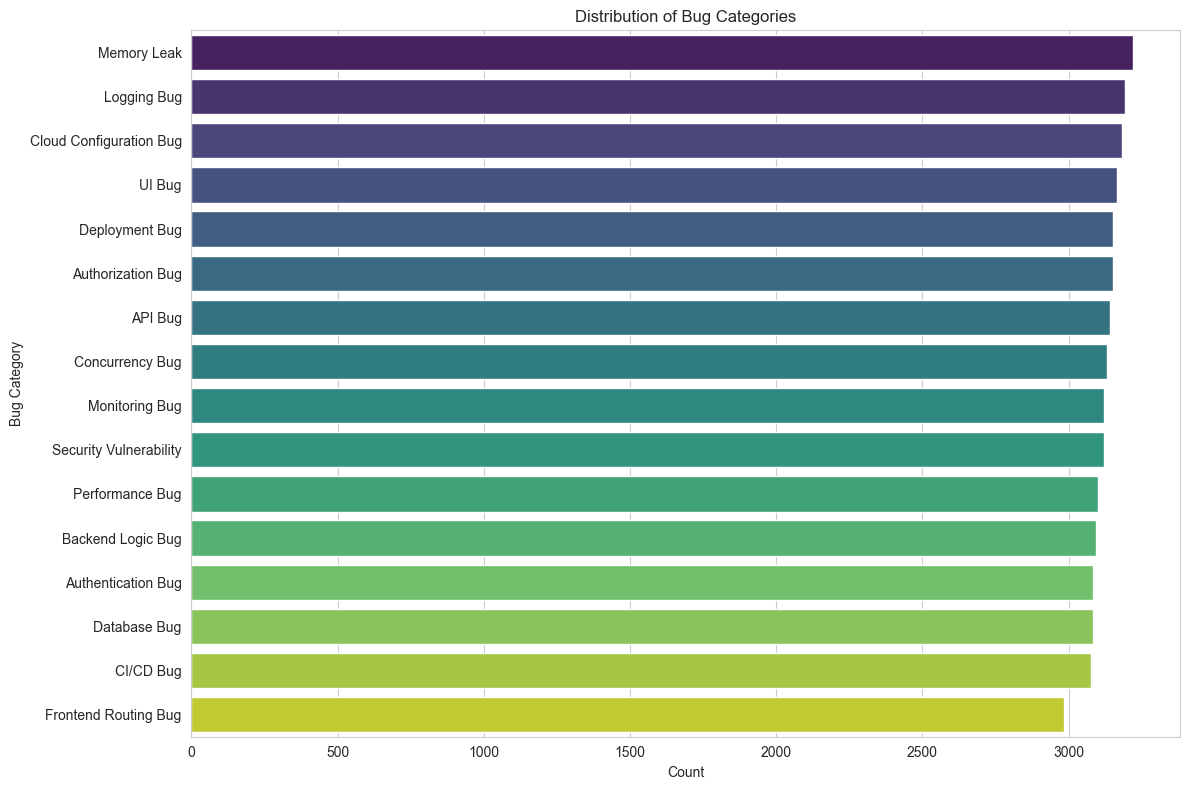

In [17]:
# Visualize the distribution of bug categories
plt.figure(figsize= (12, 8))
sns.countplot(y= "bug_category", data= df, order= df["bug_category"].value_counts().index, palette= "viridis")
plt.title("Distribution of Bug Categories")
plt.xlabel("Count")
plt.ylabel("Bug Category")
plt.tight_layout()
plt.show()

environment  bug_domain     
Development  DevOps             2823
             Backend Systems    2814
             Data               2801
             Cloud              2774
             Mobile             2768
             Web Development    2751
Production   Backend Systems    2775
             Cloud              2772
             DevOps             2751
             Web Development    2702
             Data               2683
             Mobile             2673
Staging      Backend Systems    2888
             Mobile             2870
             Data               2817
             DevOps             2790
             Cloud              2776
             Web Development    2772
Name: count, dtype: int64


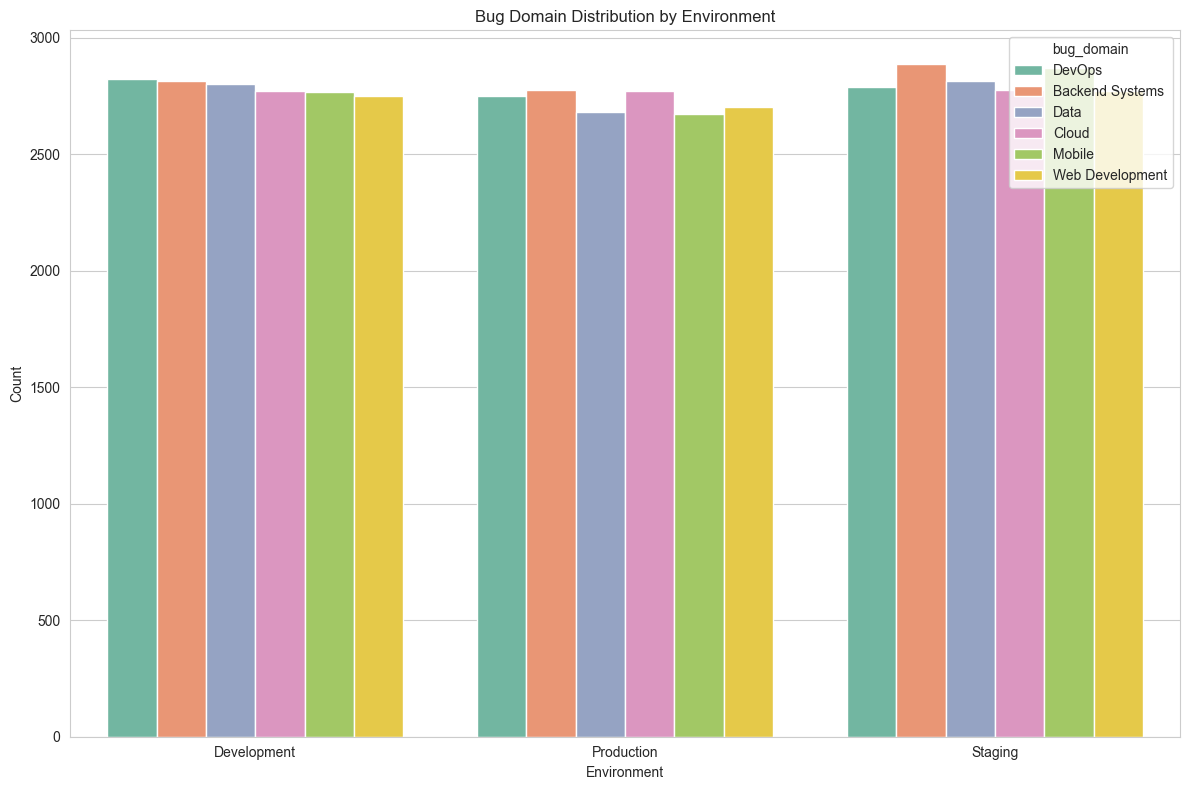

In [18]:
domain_counts= df.groupby("environment")["bug_domain"].value_counts()
print(domain_counts)

plt.figure(figsize= (12, 8))
sns.barplot(x= domain_counts.index.get_level_values(0), y= domain_counts.values, hue= domain_counts.index.get_level_values(1), palette= "Set2")
plt.title("Bug Domain Distribution by Environment")
plt.xlabel("Environment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

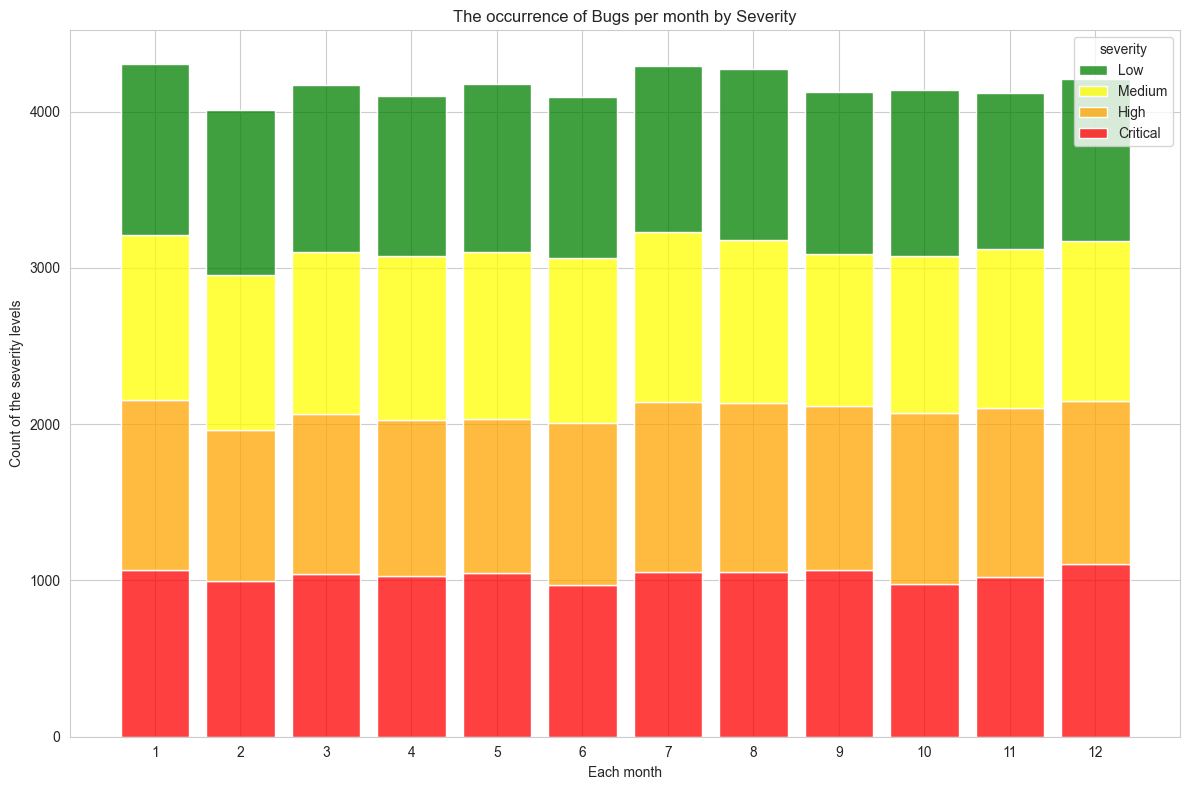

In [19]:
df["month"]= df["created_at"].dt.month

occurrence_month= df.groupby("month")["severity"].value_counts().sort_values(ascending= False)

color_severity= {"Low": "green",
                 "Medium": "yellow",
                 "High": "orange",
                 "Critical": "red"}

plt.figure(figsize= (12, 8))
sns.histplot(data= df, x= "month", hue= "severity",
             hue_order= list(color_severity.keys()), multiple= "stack", palette= color_severity, discrete= True, shrink= 0.8)
plt.title("The occurrence of Bugs per month by Severity")
plt.xlabel("Each month")
plt.ylabel("Count of the severity levels")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [20]:
# Preparing the dataset for modeling
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

In [21]:
le= LabelEncoder()

# Chnage the string values to numerical values using label encoding
df["bug_category_numerical"]= le.fit_transform(df["bug_category"]) 
df["bug_domain_numerical"]= le.fit_transform(df["bug_domain"])
df["tech_stack_numerical"]= le.fit_transform(df["tech_stack"])
df["environment_numerical"]= le.fit_transform(df["environment"])

# Convert Text Description to Numbers
tfidf= TfidfVectorizer(max_features= 800, stop_words= "english")
text_features= tfidf.fit_transform(df["description"])

# Combine all the features
# 1. Select the numerical columns
numerical_features= df[["error_code", "bug_category_numerical", "bug_domain_numerical", "tech_stack_numerical", "environment_numerical"]].values

# 2. Stack them with the text features
X= hstack([numerical_features, text_features])
# Target variable
y= df["Severity_Score"].values

In [22]:
# Drop unnecessary collumns for modeling then using the cleaned dataset
columnheaders= df.columns.tolist()
df_clean= df.drop(columns= [h for h in columnheaders if h not in ["error_code", "Severity_Score", "bug_category_numerical", "bug_domain_numerical", "tech_stack_numerical", "environment_numerical"]])
df_clean.head()

,error_code,Severity_Score,bug_category_numerical,bug_domain_numerical,tech_stack_numerical,environment_numerical
0,403.0,3,0,4,14,0
1,500.0,2,11,2,6,1
2,404.0,2,5,3,3,1
3,404.0,2,1,0,5,1
4,503.0,3,10,4,5,2


In [23]:
df_clean.describe()

,error_code,Severity_Score,bug_category_numerical,bug_domain_numerical,tech_stack_numerical,environment_numerical
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,390.04018,2.495420,7.512620,2.487700,7.456780,1.003640
std,153.70644,1.119109,4.613522,1.708645,4.614269,0.820293
min,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,401.00000,1.000000,4.000000,1.000000,3.000000,0.000000
50%,404.00000,2.000000,8.000000,2.000000,7.000000,1.000000
75%,502.00000,3.000000,12.000000,4.000000,11.000000,2.000000
max,503.00000,4.000000,15.000000,5.000000,15.000000,2.000000


In [24]:
df_clean.columns

Index(['error_code', 'Severity_Score', 'bug_category_numerical',
       'bug_domain_numerical', 'tech_stack_numerical',
       'environment_numerical'],
      dtype='object')

In [25]:
print(df_clean.isna().sum())

error_code                0
Severity_Score            0
bug_category_numerical    0
bug_domain_numerical      0
tech_stack_numerical      0
environment_numerical     0
dtype: int64


In [27]:
df_clean.to_csv("./dataset/cleaned_probset.csv", index= False)